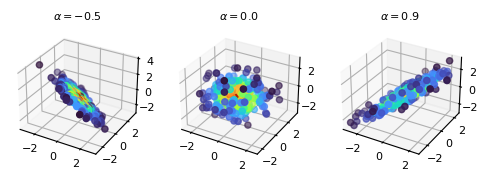

In [2]:
from scipy.stats import multivariate_normal
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.cm as cmx

SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=SMALL_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=SMALL_SIZE)  # fontsize of the figure title

mean = [0, 0, 0]
cov = lambda alpha: [[1, alpha, alpha], 
                     [alpha, 1, alpha], 
                     [alpha, alpha, 1]]
fig = plt.figure(figsize=(15/2.54, 100/2.54))
for i, alpha in enumerate([-0.499, 0, 0.9]):
    m = multivariate_normal(mean, cov(alpha))
    ax = fig.add_subplot(1, 3, i+1, projection="3d")
    n = 300
    xyz = m.rvs(n)
    x, y, z = xyz.T
    density = m.pdf(xyz)
    cm = plt.get_cmap("turbo")
    cNorm = matplotlib.colors.Normalize(vmin=min(density), vmax=max(density))
    scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cm)
    ax.scatter(x, y, z, c=scalarMap.to_rgba(density), zorder=100)
    ax.set_title(rf"$\alpha={alpha:.1f}$")
    # for axis in ax.xaxis, ax.yaxis, ax.zaxis: 
    #     axis.set_label_position("none")
    #     axis.set_ticks_position("none")
    pad = -3
    ax.tick_params(axis="x", which="both", pad=pad)
    ax.tick_params(axis="y", which="both", pad=pad)
    ax.tick_params(axis="z", which="both", pad=pad)

fig.savefig("multivariate_normal.png", dpi=300, bbox_inches="tight")
